# Analytic Solutions of the Autocorrelation and Decorrelation Scale

**Purpose**: Code for evaluating analytic solutions of the autocorrelation. 

**Luke Colosi | lcolosi@ucsd.edu**

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
import sys
import os
from datetime import datetime, timedelta
import cmocean.cm as cmo
import warnings

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_corner_label

### Background

By the Weiner-Khinchine theorem, the autocovariance function $R_{xx}(\tau)$ and the spectral density function $S_{xx}(f)$ of a random process x(t) are Fourier transform pairs and thus contain precisely the same information: 

$$
R_{xx}(\tau) = \int_{-\infty}^{\infty} S_{xx}(f) e^{2\pi i f \tau} \,df, 
$$

$$
S_{xx}(f) = \int_{-\infty}^{\infty} R_{xx}(\tau) e^{-2\pi i f \tau} \,d\tau.
$$

By the reality conidition which states that symmetry of the two-sided fourier transform of $x(t)$

$$
S_{xx}(-f) = S_{xx}(f), 
$$

we can simpilfy the integral for autocovariance

$$
R_{xx}(\tau) = 2\int_{0}^{\infty} S_{xx}(f) e^{2\pi i f \tau} \,df. 
$$

For simplicity, the subscripts will be dropped hereon. 

### Example 1: Power law spectra

Now, let us assume that the fourier transform takes the function form of a power-law spectra with a constant spectral slope

$$
S(f) = Af^{-\alpha} 
$$

where A is a constant of proportionality and $\alpha > 0$ is the spectral slope. Substituting this into the equation for the autocovariance function, we obtain: 

$$
R(\tau) = 2A\int_{0}^{\infty} f^{-\alpha} e^{2\pi i f \tau} \,df. 
$$

We evaluate this integral in the domain $f \varepsilon [f_{min}, f_{max}]$ and obtain the following analytic expression involving the upper incomplete gamma function

$$
R(\tau) = (-2 \pi i \tau)^{\alpha -1} \big[ \Gamma(1 - \alpha, -2 \pi i \tau f_{min}) - \Gamma(1 - \alpha, -2 \pi i \tau f_{max}) \big] 
$$

The result is normalized by the variance:

$$ 
R(0) =
\begin{cases}
\frac{1}{1-\alpha} \big( f_{max}^{1-\alpha} - f_{min}^{1-\alpha} \big) & \text{if } \alpha \neq 1 \\
\ln\big( \frac{f_{max}}{f_{min}} \big)  & \text{if } \alpha = 1
\end{cases}
$$

to produce the autocorrelation:

$$
\rho(\tau) = \frac{R(\tau)}{R(0)} 
$$

We visualize how the autocorrelation depends on:

1. spectral slope (alpha)
2. low-frequency cutoff (fmin)

For all calculations below, we assume $A = 1/2$. 

Set data preocessing parameters

In [2]:
# Set precision for complex special functions
mp.dps = 25

Initialize function for computing the intergal analytically

In [3]:
def autocorrelation_analytic(tau, fmin, fmax, alpha):
    """
    Function for computing the analytic autocovariance and 
    autocorrelation functions for a power-law spectrum using the 
    upper incomplete gamma function.

    This combines:
        - Upper incomplete gamma evaluation (using analytic continuation for s < 1)
        - Autocovariance computation
        - Autocorrelation computation 

    Parameters
    ----------
    tau : array-like
        Time lags.
    fmin : float
        Minimum frequency.
    fmax : float
        Maximum frequency.
    alpha : float
        Power-law exponent.

    Returns
    -------
    R : ndarray (complex)
        Autocovariance function.
    rho : ndarray (float)
        Autocorrelation function.
    R0 : float
        Variance (R at zero lag).
    """

    #-------------------------------# 
    # Upper Incomplete Gamma Function
    #-------------------------------# 
    def upper_incomplete_gamma(s, x):
        """
        Function for computing the upper incomplete gamma function \Gamma(s,x).

        Using the generalize incomplete gamma function which allows you to specify both the 
        upper and lower limits of integration for the incomplete gamma function we are evaluating: 

        \Gamma(s,z_1,z_2) = \int_{z_1}^{z_2} t^{s - 1} e^{-t} dt

        where z_2 = \infty (mp.inf), and z_1 = x (function parameter). Parameter s can be any real or complex value. 
        For Re(s) < 1, the incomplete gamma function does not converge so analytic continuation is used to 
        evaluate the integral. Singulatiries exist at zero and negative integers for \Gamma(s) and \gamma(s,x), but not for 
        \Gamma(s,x) because singluarities for \Gamma(s) and \gamma(s,x) cancel each other.   

        \Gamma(s)         = (complete) Gamma function
        \Gamma(s,x)       = Upper incomplete gamma function 
        \gamma(s,x)       = Lower incomplete gamma function 
        \Gamma(s,z_1,z_2) = generalized incomplete gamma function 

        Parameters
        ----------
        s : float or complex
            Shape parameter.
        x : float or complex
            Lower limit of integration.

        Returns
        -------
        val : complex
            Value of the upper incomplete gamma function.

        """

        # Compute upper incomplete gamma function for given s and x parameters
        upper_gamma = mp.gammainc(s, x, mp.inf)

        return upper_gamma

    #-------------------------------# 
    # Evaulation of Analytic Integral
    #-------------------------------# 
    def analytic_integral(f_lim, tau):
        """
        Function for evaluating the analytic solution of the autocovariance function:

            \int_{-2 \pi i \tau f_{lim}}^{\infty} f^{-\alpha} e^{2 \pi i \tau f} df

        Parameters
        ----------
        f_lim : float
            Frequency limit.
        tau : float
            Time lag.
        alpha : float
            Power-law exponent.

        Returns
        -------
        R : complex
            Value of the integral.
            
        """

        # Compute inputs for upper incomplete gamma function 
        s = 1 - alpha                        # Shape Parameter
        x =  -2 * np.pi * 1j * tau * f_lim   # Lower limite of integration 

        # Evaluate integral 
        R = ((-2 * np.pi * 1j * tau) ** (alpha - 1)) * upper_incomplete_gamma(s, x)

        return R

    #-------------------------------# 
    # Compute Autocovariance R(\tau)
    #-------------------------------# 

    # Initialize autocovariance function
    R = []

    # Loop through time lags 
    for itau in tau:

        # Compute the integral using the upper incomplete gamma function for f_min and f_max lower limits
        R_fmax = analytic_integral(fmax, itau)
        R_fmin = analytic_integral(fmin, itau)

        # Evaluate the integral between f_max and f_min for the ith time lag
        R.append(R_fmin - R_fmax)

    # Convert to a numpy array
    R = np.array([complex(r) for r in R])

    #-------------------------------# 
    # Compute R(0) (Variance)
    #-------------------------------# 
    if np.isclose(alpha, 1.0):
        R0 = np.log(fmax / fmin)
    else:
        R0 = (fmax**(1 - alpha) - fmin**(1 - alpha)) / (1 - alpha)

    #-------------------------------# 
    # Compute Autocorrelaton \rho(\tau)
    #-------------------------------# 
    rho = np.real(R) / R0

    return R, rho, R0

<>:38: SyntaxWarning: invalid escape sequence '\G'
<>:81: SyntaxWarning: invalid escape sequence '\i'
<>:38: SyntaxWarning: invalid escape sequence '\G'
<>:81: SyntaxWarning: invalid escape sequence '\i'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_7915/3284539977.py:38: SyntaxWarning: invalid escape sequence '\G'
  Function for computing the upper incomplete gamma function \Gamma(s,x).
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_7915/3284539977.py:81: SyntaxWarning: invalid escape sequence '\i'
  \int_{-2 \pi i \tau f_{lim}}^{\infty} f^{-\alpha} e^{2 \pi i \tau f} df


Set parameters for computing the autocorrelation function

In [42]:
# Set sampling parameters 
dt = 1/24                                                # Sampling interval (units: days) 
T_ac  = np.array([3/12, 6/12, 8/12, 1]) * (365)             # Record duration (units: days)

# Set time lag (avoid t = 0 singularity)
tau = np.linspace(dt, max(T_ac), 200)   # Units: days

# Set maximum and minimum frequency in units of cpd
fmax = 1/dt                                         
fmin_values = 1/T_ac               

# Set spectral slope values 
alpha_values_ac = [1.5, 2.0, 3.0, 4.0, 5.0]

Compute autocorrelation function

In [5]:
# Set parameters
nfmin, nalpha, ntau = len(fmin_values), len(alpha_values_ac), len(tau)

# Initialize array
rho = np.zeros((ntau, nfmin, nalpha))

# Loop through f_min (low frequency bound)
for i, fmin in enumerate(fmin_values):

    # Loop through spectral slope
    for j, alpha in enumerate(alpha_values_ac):

        # Compute the autocorrelation function 
        _, rho[:,i,j], _ = autocorrelation_analytic(tau, fmin, fmax, alpha)

Set plotting parameters

In [6]:
# Set parameters
fontsize = 16
x_max = 4

# Compute duration to number of months
days_per_month = 365 / 12   
T_months_ac    = np.round(T / days_per_month)
tau_months     = tau / days_per_month

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

# Set path to save figures 
PATH_figs = ROOT + 'AirSeaCoupling/figs/paper_figures/'

Plot Autocorrelation functions 

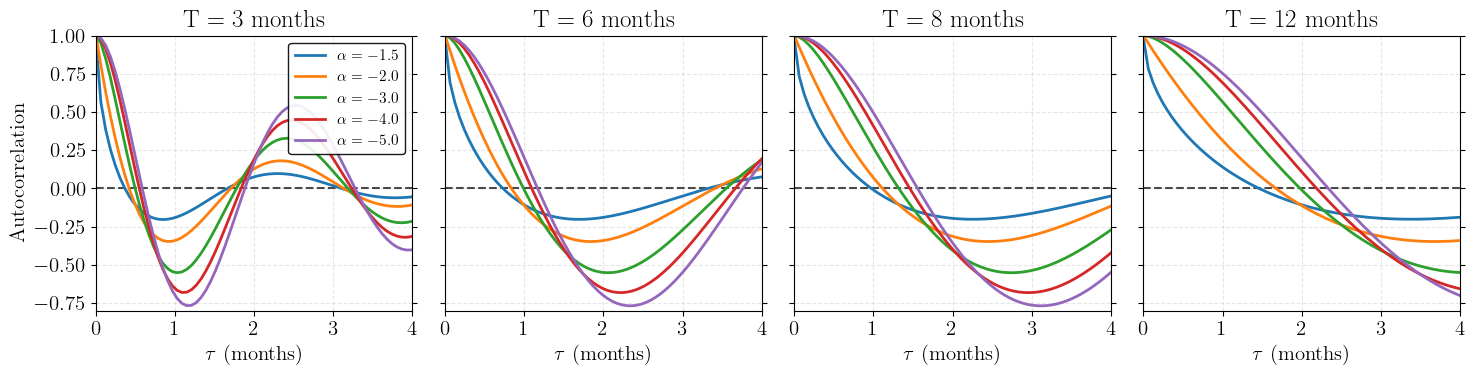

In [7]:
# Create figure and axes 
fig, axes = plt.subplots(1, nfmin, figsize=(15, 4))

# Loop through f_min values 
for k in range(0,len(fmin_values)): 

    # Set axis object 
    ax = axes[k]

    # Plot the zero autocorrelation line 
    ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

    # Loop through alpha values
    for i, ialpha in enumerate(alpha_values_ac):

        # Plot the ith alpha value 
        ax.plot(tau_months, rho[:,k,i], '-', lw = 2, label=rf"$\alpha = -{ialpha}$") 

    # Set axis attributes 
    ax.set_title(f'T = {int(T_months_ac[k])} months')
    ax.set_xlabel(r'$\tau$ (months)')
    ax.set_xticks(np.arange(0,12+1,1))
    ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
    ax.set_xlim(-0,x_max)
    ax.set_ylim(-0.8,1)
    ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
    ax.grid(True,linestyle='--',alpha=0.3)

    if k == 0: 
        ax.set_ylabel('Autocorrelation')
        ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')
    else: 
        ax.set_yticklabels([])

# Display 
plt.tight_layout()
plt.show()

Plot autocorrelation in stretch coordinates $\tau f_{min}$ to test if the autocorrelation function collapses. This is a test of self-similarity. 

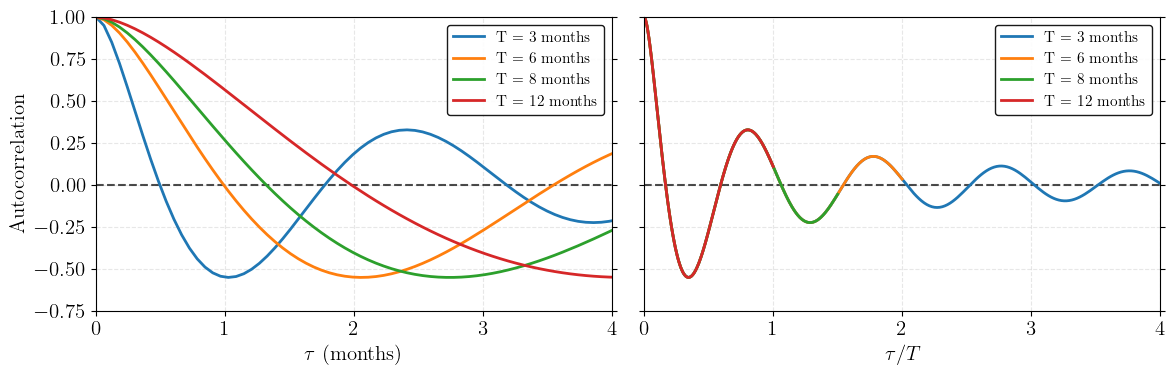

In [8]:
# Set plotting parameters
idx_alpha = np.argmin(np.abs(np.array(alpha_values_ac) - 3))

# Create figure and axes 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#-------------------# 
# Subplot 1
#-------------------# 
ax = axes[0]

# Plot the zero autocorrelation line 
ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

# Loop through f_min values 
for k in range(0,len(fmin_values)): 

    # Plot the ith alpha value 
    ax.plot(tau_months, rho[:,k,idx_alpha], '-', lw = 2, label=f"T = {int(T_months_ac[k])} months") 

# Set axis attributes 
ax.set_ylabel('Autocorrelation')
ax.set_xlabel(r'$\tau$ (months)')
ax.set_xticks(np.arange(0,12+1,1))
ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
ax.set_xlim(0,x_max)
ax.set_ylim(-0.75,1)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 2
#-------------------# 
ax = axes[1]

# Plot the zero autocorrelation line 
ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

# Loop through f_min values 
for k in range(len(T_months_ac)): 

    # Plot the ith alpha value 
    ax.plot(tau_months/T_months_ac[k], rho[:,k,idx_alpha], '-', lw = 2, label=f"T = {int(T_months_ac[k])} months") 

# Set axis attributes 
ax.set_xlabel(r'$\tau / T$')
ax.set_xticks(np.arange(0,4+1,1))
ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
ax.set_xlim(0,4)
ax.set_ylim(-0.75,1)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Display 
plt.tight_layout()
plt.show()

Next, we compute the decorrelation time scale analytically from the autocorrelation function

$$
\widetilde{T} = \int_{0}^{\infty} \rho(\tau) d\tau.
$$

Using the example from above, the decorrelation scale involves evaluating this integral

$$
\widetilde{T} = \frac{(-2 \pi i)^{\alpha - 1}}{R(0)} \bigg[ \int_{0}^{\infty} \tau^{\alpha -1} \Gamma(1 - \alpha, -2 \pi i \tau f_{min}) d\tau - \int_{0}^{\infty} \tau^{\alpha -1} \Gamma(1 - \alpha, -2 \pi i \tau f_{max}) d\tau \bigg]. 
$$

We evaluate this integral and obtain the following analytic expression involving the upper incomplete gamma function: 

$$
\widetilde{T} = \frac{1}{-2\pi i \alpha R(0)} \cdot \big[ f_{min}^{-\alpha}  - f_{max}^{-\alpha} \big]
$$

where 

$$ 
R(0) =
\begin{cases}
\frac{1}{1-\alpha} \big( f_{max}^{1-\alpha} - f_{min}^{1-\alpha} \big) & \text{if } \alpha \neq 1 \\
\ln\big( \frac{f_{max}}{f_{min}} \big)  & \text{if } \alpha = 1
\end{cases}
$$

We visualize how the decorrelation time scale depends on:

1. Spectral slope ($\alpha$)
2. Low-frequency cutoff ($f_{min}$)

For all calculations below, we again assume $A = 1/2$. 


In [9]:
def decorrelation_scale_analytic(fmin, fmax, alpha):
    """
    Function for computing the analytic decorrelation scale for a power-law spectrum. 

    Parameters
    ----------
    fmin : float
        Minimum frequency.
    fmax : float
        Maximum frequency.
    alpha : float
        Power-law exponent.

    Returns
    -------
    T : ndarray (complex)
        Decorrelation scale.
    R0 : float
        Variance (R at zero lag).
    """

    #-------------------------------# 
    # Compute R(0) (Variance)
    #-------------------------------# 
    if np.isclose(alpha, 1.0):
        R0 = np.log(fmax / fmin)
    else:
        R0 = (fmax**(1 - alpha) - fmin**(1 - alpha)) / (1 - alpha)

    #-------------------------------# 
    # Compute decorrelaton scale
    #-------------------------------# 
    T = (1/(-2 * np.pi * 1j * alpha * R0)) * (fmin**(-alpha) - fmax**(-alpha)) 

    return np.imag(T), R0

Set parameters for computing the autocorrelation function

In [10]:
# Set sampling parameters 
dt = 1/24                                                # Sampling interval (units: days) 
T  = np.flipud(np.arange(0.025, 1 + 0.025, 0.025) * (365))  # Record duration (units: days)

# Convert time to units of months 
days_per_month = 365 / 12 
T_months = T / days_per_month

# Set maximum and minimum frequency in units of cpd
fmax = 1/dt                                         
fmin_values = 1/T               

# Set spectral slope values 
alpha_values = np.arange(0.1,5+0.1,0.1)

Compute decorrelation scale

In [11]:
# Set parameters
nfmin, nalpha = len(fmin_values), len(alpha_values)

# Initialize array
T_tilde = np.zeros((nfmin, nalpha))

# Loop through f_min (low frequency bound)
for i, fmin in enumerate(fmin_values):

    # Loop through spectral slope
    for j, alpha in enumerate(alpha_values):

        # Compute the autocorrelation function 
        T_tilde[i,j], _ = decorrelation_scale_analytic(fmin, fmax, alpha)   # Units: days

Plot the decorrelation scale as a function of spectral slope and duration 

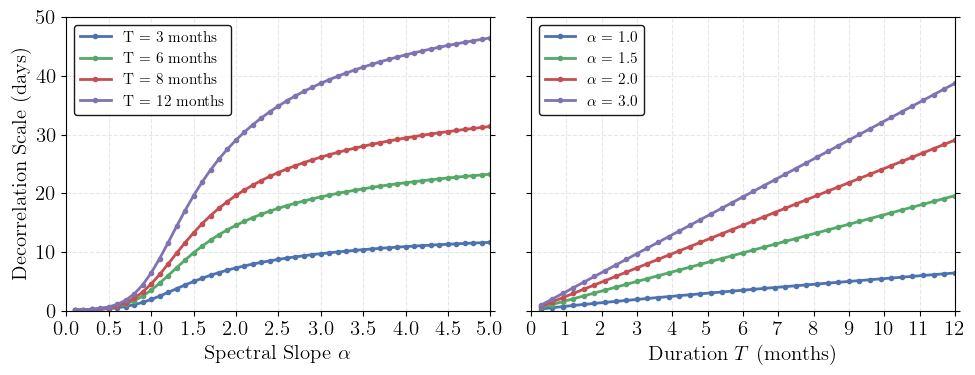

In [12]:
# Set plotting parameters
colors_decor = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
alpha_p    = [1, 1.5, 2, 3]
T_months_p = [3,6,8,12]

# Create figure and axes 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#-------------------# 
# Subplot 1
#-------------------# 
ax = axes[0]

# Loop through a subset of T values 
for k, iT in enumerate(T_months_p): 

    # Find index value
    idx_T = np.argmin(np.abs(T_months - iT))

    # Plot the decorrelation scale as a function of spectral slope
    ax.plot(alpha_values, T_tilde[idx_T,:], '.-', lw = 2, label=f"T = {int(T_months[idx_T])} months", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel('Decorrelation Scale (days)')
ax.set_xticks(np.arange(0,5+0.5,0.5))
ax.set_yticks(np.arange(0,50+10,10))
ax.set_xlim(0,5)
ax.set_ylim(0,50)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper left', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 2
#-------------------# 
ax = axes[1]

# Loop through a subset of alpha values 
for k, ialpha in enumerate(alpha_p): 

    # Find index value
    idx_alpha = np.argmin(np.abs(np.array(alpha_values) - ialpha))

    # Plot the decorrelation scale as a function of f_min
    ax.plot(T_months, T_tilde[:,idx_alpha], '.-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values[idx_alpha],1)}", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'Duration $T$ (months)')
ax.set_xticks(np.arange(0,12+1,1))
ax.set_yticks(np.arange(0,50+10,10))
ax.set_xlim(0,12)
ax.set_ylim(0,50)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper left', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Display 
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_7915/1505668622.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


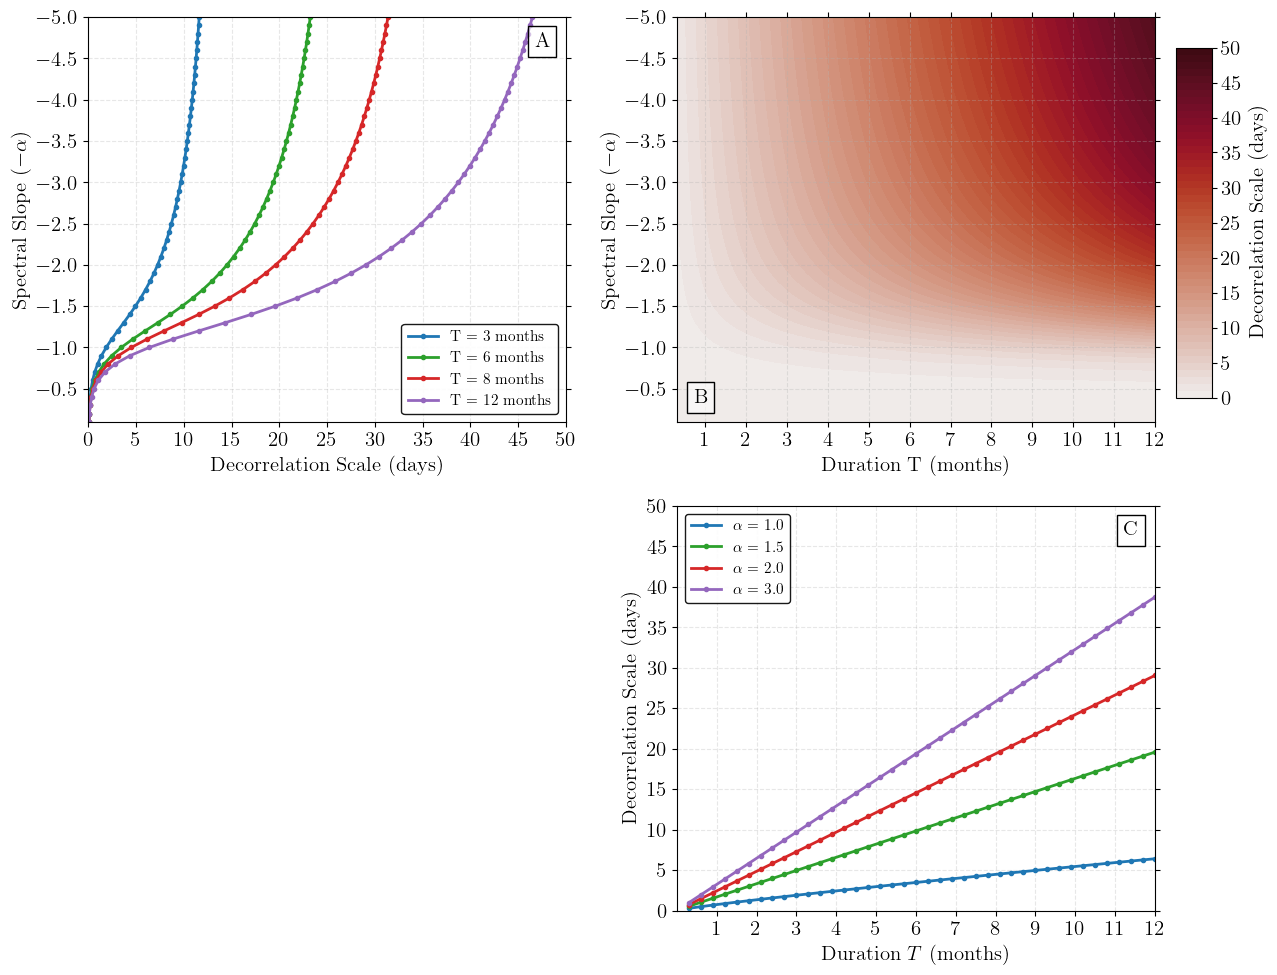

In [13]:
# Set plotting parameters
colors_decor = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple'] #['#4c72b0', '#55a868', '#c44e52', '#8172b2']
alpha_p    = [1, 1.5, 2, 3]
T_months_p = [3, 6, 8, 12]
levels     = np.arange(0,50+1,1)

# Create figure and axes 
fig,axes = plt.subplots(2,2,figsize=(12, 10))

#-------------------# 
# Subplot 1
#-------------------# 
ax = axes[0,0]

# Loop through a subset of T values 
for k, iT in enumerate(T_months_p): 

    # Find index value
    idx_T = np.argmin(np.abs(T_months - iT))

    # Plot the decorrelation scale as a function of spectral slope
    ax.plot(T_tilde[idx_T,:], -1*alpha_values, '.-', lw = 2, label=f"T = {int(T_months[idx_T])} months", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel('Decorrelation Scale (days)')
ax.set_ylabel(r'Spectral Slope ($-\alpha$)')
ax.set_xticks(np.arange(0,50+5,5))
ax.set_yticks(np.arange(-5, 0,0.5))
ax.set_xlim(0,50)
ax.set_ylim(-5,-0.1)
ax.invert_yaxis()
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='lower right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 2
#-------------------#  
ax = axes[0,1]

# Plot decorrelation scale
pc = ax.contourf(T_months, -1*alpha_values, T_tilde.T, levels=levels, cmap=cmo.amp)

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Spectral Slope ($-\alpha$)')
ax.set_xticks(np.arange(1,12+1,1))
ax.set_yticks(np.arange(-5, 0,0.5))
ax.set_ylim(-5,-0.1)
ax.invert_yaxis()
ax.grid(True,linestyle='--',alpha=0.3)
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.99, 0.59, 0.03, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 50)
ticks = np.arange(0, 50+5, 5)
cbar.set_ticks(ticks)
# labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
# cbar.set_ticklabels(labels)

#-------------------# 
# Subplot 3
#-------------------# 
ax = axes[1,0]

# Supress axis
ax.axis('off')

#-------------------# 
# Subplot 4
#-------------------# 
ax = axes[1,1]

# Loop through a subset of alpha values 
for k, ialpha in enumerate(alpha_p): 

    # Find index value
    idx_alpha = np.argmin(np.abs(np.array(alpha_values) - ialpha))

    # Plot the decorrelation scale as a function of f_min
    ax.plot(T_months, T_tilde[:,idx_alpha], '.-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values[idx_alpha],1)}", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'Duration $T$ (months)')
ax.set_ylabel('Decorrelation Scale (days)')
ax.set_xticks(np.arange(1,12+1,1))
ax.set_yticks(np.arange(0,50+5,5))
ax.set_xlim(0,12)
ax.set_ylim(0,50)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper left', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Label each subplot
ax1, ax2, ax3, ax4 = axes.flatten()
pos = [0.95, 0.94]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, [0.05,0.06], 'B', fontsize = fontsize)
add_corner_label(ax4, pos, 'C', fontsize = fontsize)

# Adjust spacing
plt.tight_layout()
plt.show()

# Save figure in high resolution 
figName = 'fig02.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

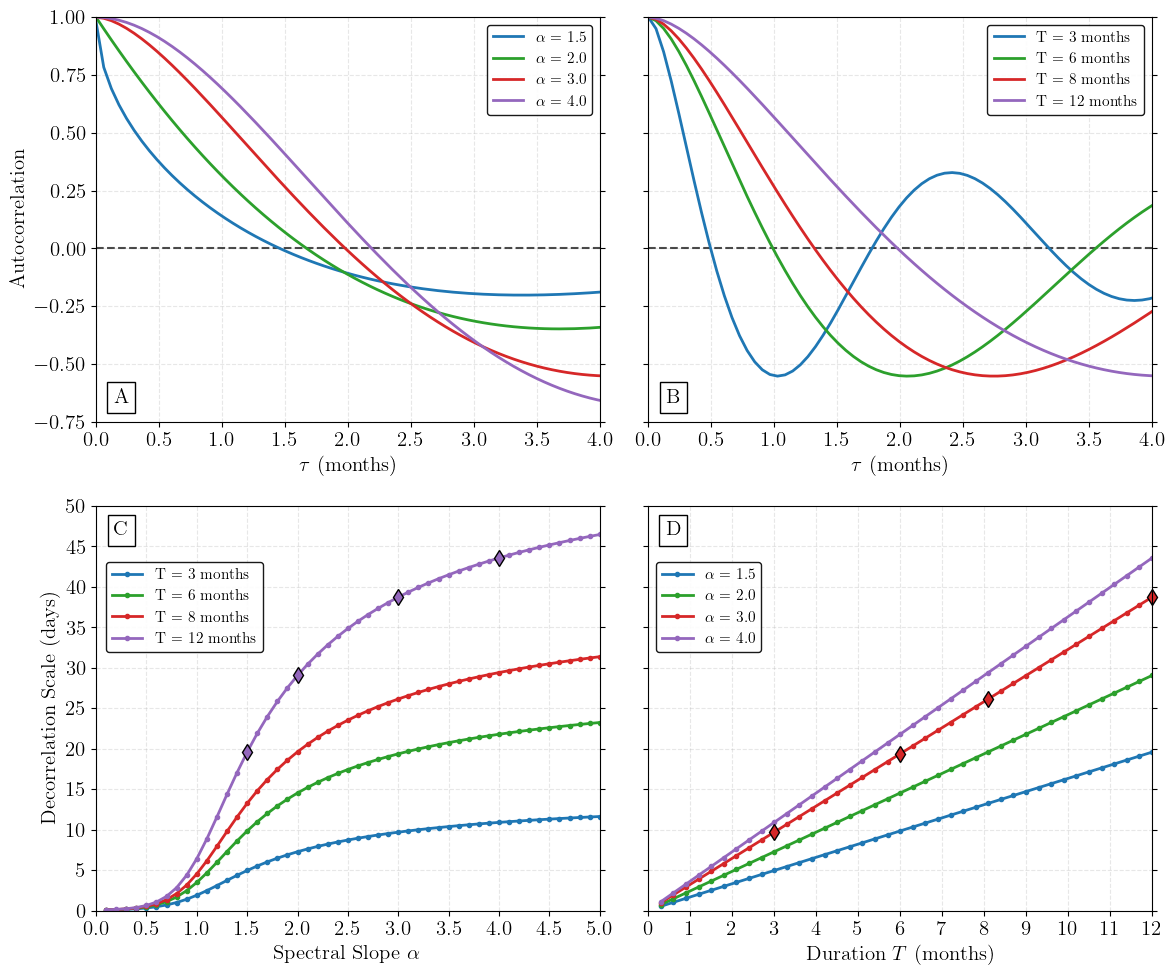

In [34]:
# Set plotting parameters
colors_decor = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:orange'] #['#4c72b0', '#55a868', '#c44e52', '#8172b2']
alpha_p      = [1.5, 2, 3, 4]
T_months_p   = [3, 6, 8, 12]
idx_alpha_ac = np.argmin(np.abs(np.array(alpha_values_ac) - 3))
idx_T_ac     = np.argmin(np.abs(np.array(T_months_ac) - 12))
x_max        = 4

# Create figure and axes 
fig,axes = plt.subplots(2,2,figsize=(12, 10))

#-------------------# 
# Subplot 1
#-------------------# 
ax = axes[0,0]

# Plot the zero autocorrelation line 
ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

# Loop through alpha values 
for k in range(0,len(alpha_values_ac[:-1])): 

    # Plot the ith alpha value 
    ax.plot(tau_months, rho[:,idx_T_ac,k], '-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values_ac[k],1)}", color=colors_decor[k]) 

# Set axis attributes 
ax.set_ylabel('Autocorrelation')
ax.set_xlabel(r'$\tau$ (months)')
ax.set_xticks(np.arange(0,12+0.5,0.5))
ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
ax.set_xlim(0,x_max)
ax.set_ylim(-0.75,1)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 2
#-------------------#  
ax = axes[0,1]

# Plot the zero autocorrelation line 
ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

# Loop through f_min values 
for k in range(0,len(T_months_ac)): 

    # Plot the ith autocorrelation function for the ith T value 
    ax.plot(tau_months, rho[:,k,idx_alpha_ac], '-', lw = 2, label=f"T = {int(T_months_ac[k])} months", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'$\tau$ (months)')
ax.set_xticks(np.arange(0,12+0.5,0.5))
ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
ax.set_xlim(0,x_max)
ax.set_ylim(-0.75,1)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 3
#-------------------# 
ax = axes[1,0]

# Loop through a subset of T values 
for k, iT in enumerate(T_months_p): 

    # Find index value
    idx_T = np.argmin(np.abs(T_months - iT))

    # Plot the decorrelation scale as a function of spectral slope
    ax.plot(alpha_values, T_tilde[idx_T,:], '.-', lw = 2, label=f"T = {int(T_months[idx_T])} months", color=colors_decor[k]) 

# Plot markers for decorrelation scales for alpha = 1.5, 2, 3, 4 and T = 12 months
idx_t = np.argmin(np.abs(T_months - 12))
idx_a1 = np.argmin(np.abs(alpha_values - 1.5))
idx_a2 = np.argmin(np.abs(alpha_values - 2))
idx_a3 = np.argmin(np.abs(alpha_values - 3))
idx_a4 = np.argmin(np.abs(alpha_values - 4))
ax.plot(alpha_values[idx_a1], T_tilde[idx_t, idx_a1], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(alpha_values[idx_a2], T_tilde[idx_t, idx_a2], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(alpha_values[idx_a3], T_tilde[idx_t, idx_a3], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(alpha_values[idx_a4], T_tilde[idx_t, idx_a4], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)

# Set axis attributes 
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel('Decorrelation Scale (days)')
ax.set_xticks(np.arange(0,5+0.5,0.5))
ax.set_yticks(np.arange(0,50+5,5))
ax.set_xlim(0,5)
ax.set_ylim(0,50)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='center', bbox_to_anchor=(0.175, 0.75), fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 4
#-------------------# 
ax = axes[1,1]

# Loop through a subset of alpha values 
for k, ialpha in enumerate(alpha_p): 

    # Find index value
    idx_alpha = np.argmin(np.abs(np.array(alpha_values) - ialpha))

    # Plot the decorrelation scale as a function of f_min
    ax.plot(T_months, T_tilde[:,idx_alpha], '.-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values[idx_alpha],1)}", color=colors_decor[k]) 

# Plot markers for decorrelation scales for alpha = 3 and T = 3, 6, 8, 12 months
idx_t3 = np.argmin(np.abs(T_months - 3))
idx_t6 = np.argmin(np.abs(T_months - 6))
idx_t8 = np.argmin(np.abs(T_months - 8))
idx_t12 = np.argmin(np.abs(T_months - 12))
idx_a = np.argmin(np.abs(alpha_values - 3))
ax.plot(T_months[idx_t3], T_tilde[idx_t3, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(T_months[idx_t6], T_tilde[idx_t6, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(T_months[idx_t8], T_tilde[idx_t8, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(T_months[idx_t12], T_tilde[idx_t12, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1, clip_on=False)

# Set axis attributes 
ax.set_xlabel(r'Duration $T$ (months)')
ax.set_xticks(np.arange(0,12+1,1))
ax.set_yticks(np.arange(0,50+5,5))
ax.set_xlim(0,12)
ax.set_ylim(0,50)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='center', bbox_to_anchor=(0.12, 0.75), fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Label each subplot
ax1, ax2, ax3, ax4 = axes.flatten()
add_corner_label(ax1, [0.05,0.06], 'A', fontsize = fontsize)
add_corner_label(ax2, [0.05,0.06], 'B', fontsize = fontsize)
add_corner_label(ax3, [0.05,0.94], 'C', fontsize = fontsize)
add_corner_label(ax4, [0.05,0.94], 'D', fontsize = fontsize)

# Adjust spacing
plt.tight_layout()
plt.show()

# # Save figure in high resolution 
# figName = 'fig02.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )

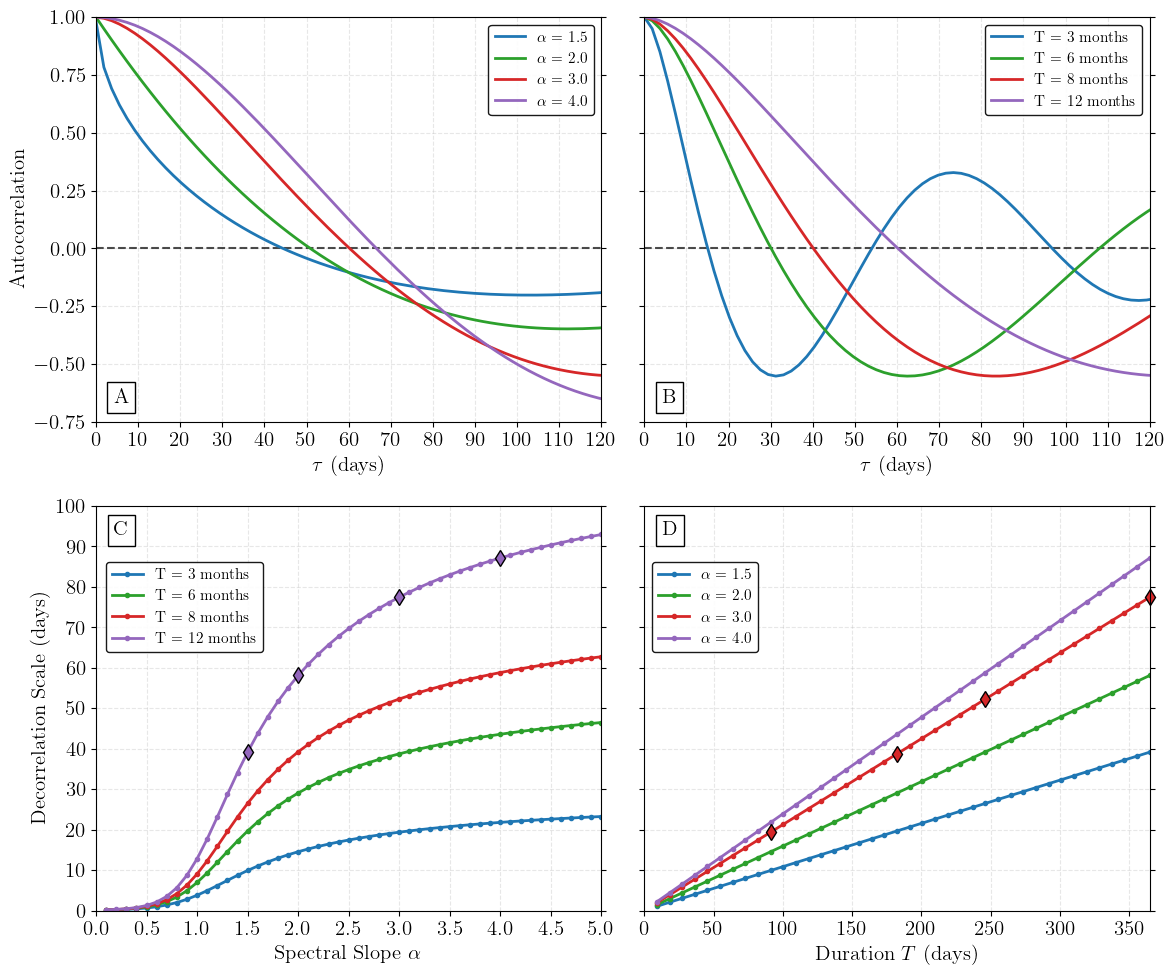

In [59]:
# Set plotting parameters
colors_decor = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:orange'] #['#4c72b0', '#55a868', '#c44e52', '#8172b2']
alpha_p      = [1.5, 2, 3, 4]
idx_alpha_ac = np.argmin(np.abs(np.array(alpha_values_ac) - 3))
idx_T_ac     = np.argmin(np.abs(np.array(T_months_ac) - 12))
x_max        = 4

# Create figure and axes 
fig,axes = plt.subplots(2,2,figsize=(12, 10))

#-------------------# 
# Subplot 1
#-------------------# 
ax = axes[0,0]

# Plot the zero autocorrelation line 
ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

# Loop through alpha values 
for k in range(0,len(alpha_values_ac[:-1])): 

    # Plot the ith alpha value 
    ax.plot(tau, rho[:,idx_T_ac,k], '-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values_ac[k],1)}", color=colors_decor[k]) 

# Set axis attributes 
ax.set_ylabel('Autocorrelation')
ax.set_xlabel(r'$\tau$ (days)')
ax.set_xticks(np.arange(0,365+10,10))
ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
ax.set_xlim(0,120)
ax.set_ylim(-0.75,1)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 2
#-------------------#  
ax = axes[0,1]

# Plot the zero autocorrelation line 
ax.axhline(0, ls = '--', lw = 1.5, alpha = 0.7, color='k')

# Loop through f_min values 
for k in range(0,len(T_months_ac)): 

    # Plot the ith autocorrelation function for the ith T value 
    ax.plot(tau, rho[:,k,idx_alpha_ac], '-', lw = 2, label=f"T = {int(T_months_ac[k])} months", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'$\tau$ (days)')
ax.set_xticks(np.arange(0,365+10,10))
ax.set_yticks(np.arange(-0.75,1+0.25,0.25))
ax.set_xlim(0,120)
ax.set_ylim(-0.75,1)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 3
#-------------------# 
ax = axes[1,0]

# Loop through a subset of T values 
for k, iT in enumerate(T_months_p): 

    # Find index value
    idx_T = np.argmin(np.abs(T_months - iT))

    # Plot the decorrelation scale as a function of spectral slope
    ax.plot(alpha_values, 2*T_tilde[idx_T,:], '.-', lw = 2, label=f"T = {int(T_months[idx_T])} months", color=colors_decor[k]) 

# Plot markers for decorrelation scales for alpha = 1.5, 2, 3, 4 and T = 12 months
idx_t = np.argmin(np.abs(T_months - 12))
idx_a1 = np.argmin(np.abs(alpha_values - 1.5))
idx_a2 = np.argmin(np.abs(alpha_values - 2))
idx_a3 = np.argmin(np.abs(alpha_values - 3))
idx_a4 = np.argmin(np.abs(alpha_values - 4))
ax.plot(alpha_values[idx_a1], 2*T_tilde[idx_t, idx_a1], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(alpha_values[idx_a2], 2*T_tilde[idx_t, idx_a2], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(alpha_values[idx_a3], 2*T_tilde[idx_t, idx_a3], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(alpha_values[idx_a4], 2*T_tilde[idx_t, idx_a4], 'd', color='tab:purple', markersize=8, markeredgecolor='black', markeredgewidth=1)

# Set axis attributes 
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel('Decorrelation Scale (days)')
ax.set_xticks(np.arange(0,5+0.5,0.5))
ax.set_yticks(np.arange(0,100+10,10))
ax.set_xlim(0,5)
ax.set_ylim(0,100)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='center', bbox_to_anchor=(0.175, 0.75), fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 4
#-------------------# 
ax = axes[1,1]

# Loop through a subset of alpha values 
for k, ialpha in enumerate(alpha_p): 

    # Find index value
    idx_alpha = np.argmin(np.abs(np.array(alpha_values) - ialpha))

    # Plot the decorrelation scale as a function of f_min
    ax.plot(T, 2*T_tilde[:,idx_alpha], '.-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values[idx_alpha],1)}", color=colors_decor[k]) 

# Plot markers for decorrelation scales for alpha = 3 and T = 3, 6, 8, 12 months
idx_t3 = np.argmin(np.abs(T_months - 3))
idx_t6 = np.argmin(np.abs(T_months - 6))
idx_t8 = np.argmin(np.abs(T_months - 8))
idx_t12 = np.argmin(np.abs(T_months - 12))
idx_a = np.argmin(np.abs(alpha_values - 3))
ax.plot(T[idx_t3], 2*T_tilde[idx_t3, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(T[idx_t6], 2*T_tilde[idx_t6, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(T[idx_t8], 2*T_tilde[idx_t8, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1)
ax.plot(T[idx_t12], 2*T_tilde[idx_t12, idx_a], 'd', color='tab:red', markersize=8, markeredgecolor='black', markeredgewidth=1, clip_on=False)

# Set axis attributes 
ax.set_xlabel(r'Duration $T$ (days)')
ax.set_yticks(np.arange(0,100+10,10))
ax.set_xlim(0,365)
ax.set_ylim(0,100)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='center', bbox_to_anchor=(0.12, 0.75), fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Label each subplot
ax1, ax2, ax3, ax4 = axes.flatten()
add_corner_label(ax1, [0.05,0.06], 'A', fontsize = fontsize)
add_corner_label(ax2, [0.05,0.06], 'B', fontsize = fontsize)
add_corner_label(ax3, [0.05,0.94], 'C', fontsize = fontsize)
add_corner_label(ax4, [0.05,0.94], 'D', fontsize = fontsize)

# Adjust spacing
plt.tight_layout()
plt.show()

# Save figure in high resolution 
figName = 'fig02.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Next, we can extend this result to structure functions using the relation between the autocorrelation function and the second order structure function. Recall that the second order structure function of the time series $x(t)$ is defined as

$$
S_2(\tau) = \langle [x(t + \tau)  - x(t)]^2\rangle _t,
$$

the mean squared difference between data points separated by a time interval $\tau$, where $\langle \cdot \rangle _t$ denotes averaging over all time. Expanding the quadratic term within the expectation operator, we obtain

$$
\langle [x(t + \tau)  - x(t)]^2\rangle _t = \langle x^2(t + \tau)  + x^2(t) - 2x(t + \tau)x(t) \rangle _t
$$

The expectation operator is linear, so we can distribute it to each term (for simplicity, we will drop the t subscript)

$$
\langle x^2(t + \tau) \rangle + \langle x^2(t)  \rangle - 2 \langle x(t + \tau)x(t) \rangle 
$$

For a stationary process, statistical moments are time-invariant, so 

$$
\langle x(t + \tau)^2 \rangle = \langle x^2(t)  \rangle \equiv \langle x^2  \rangle
$$

Therefore, 

$$
S_2 = 2 \langle x^2  \rangle - 2\langle x(t + \tau)x(t) \rangle. 
$$

Next, recall that the variance and autocovariance is defined as

$$
\sigma^2 = \langle x^2(t) \rangle - \mu^2, \\
R(\tau) = \langle (x(t + \tau) - \mu) (x(t) - \mu) \rangle.
$$

Expanding the autocovariance function and applying the expectation operating, we obtain $R(\tau) = \langle x(t + \tau)x(t)\rangle - \mu^2$. Rearranging these equations 

$$
\langle x^2(t) \rangle = \sigma^2 + \mu^2,
\langle x(t + \tau)x(t)\rangle = R(\tau) + \mu^2,
$$

we can substitute these into the equation for the structure function

$$
S_2 = 2 [\sigma^2 + \mu^2] - 2[R(\tau) + \mu^2]\\
$$

Simplifying the expression gives us a equation for S_2 independent of the mean

$$
S_2(\tau) = 2\sigma^2 - 2R(\tau)
$$

Lastely, we can divide through by $2\sigma^2$ to obtain

$$
\frac{S_2(\tau)}{2\sigma^2} = 1 - \frac{R(\tau)}{\sigma^2} = 1 - \rho(\tau)
$$

Rearranging provides use with a relationship between the autocorrelation and structure function

$$
\rho(\tau) = 1 - \frac{S_2(\tau)}{2\sigma^2} = 1 - \frac{S_2(\tau)}{2\langle x'^2\rangle}
$$

This shows clearly that the structure function does not have explicit dependence on either the mean or variance of the time series, whereas the autocorrelation strongly depends on both. Using this formulation, we can derive the structure function from the analytic solution for the autocovariance for a power-law spectrum 

$$
S_2(\tau) = 2R(0) + 2\cdot(-2 \pi i \tau)^{\alpha -1} \big[ \Gamma(1 - \alpha, -2 \pi i \tau f_{min}) - \Gamma(1 - \alpha, -2 \pi i \tau f_{max}) \big]
$$

where

$$ 
R(0) =
\begin{cases}
\frac{1}{1-\alpha} \big( f_{max}^{1-\alpha} - f_{min}^{1-\alpha} \big) & \text{if } \alpha \neq 1 \\
\ln\big( \frac{f_{max}}{f_{min}} \big)  & \text{if } \alpha = 1
\end{cases}
$$

We visualize how the structure function depends on:

1. Spectral slope (alpha)
2. Low-frequency cutoff (fmin)

For all calculations below, we again assume $A = 1/2$. 

Initialize function for computing the intergal analytically

In [14]:
def structure_func_analytic(tau, fmin, fmax, alpha):
    """
    Function for computing the analytic second order structure function for a power-law spectrum using the 
    upper incomplete gamma function.

    Parameters
    ----------
    tau : array-like
        Time lags.
    fmin : float
        Minimum frequency.
    fmax : float
        Maximum frequency.
    alpha : float
        Power-law exponent.

    Returns
    -------
    R : ndarray (complex)
        Autocovariance function.
    S : ndarray (float)
        Structure function.
    R0 : float
        Variance (R at zero lag).
    """

    #-------------------------------# 
    # Upper Incomplete Gamma Function
    #-------------------------------# 
    def upper_incomplete_gamma(s, x):
        """
        Function for computing the upper incomplete gamma function \Gamma(s,x).

        Using the generalize incomplete gamma function which allows you to specify both the 
        upper and lower limits of integration for the incomplete gamma function we are evaluating: 

        \Gamma(s,z_1,z_2) = \int_{z_1}^{z_2} t^{s - 1} e^{-t} dt

        where z_2 = \infty (mp.inf), and z_1 = x (function parameter). Parameter s can be any real or complex value. 
        For Re(s) < 1, the incomplete gamma function does not converge so analytic continuation is used to 
        evaluate the integral. Singulatiries exist at zero and negative integers for \Gamma(s) and \gamma(s,x), but not for 
        \Gamma(s,x) because singluarities for \Gamma(s) and \gamma(s,x) cancel each other.   

        \Gamma(s)         = (complete) Gamma function
        \Gamma(s,x)       = Upper incomplete gamma function 
        \gamma(s,x)       = Lower incomplete gamma function 
        \Gamma(s,z_1,z_2) = generalized incomplete gamma function 

        Parameters
        ----------
        s : float or complex
            Shape parameter.
        x : float or complex
            Lower limit of integration.

        Returns
        -------
        val : complex
            Value of the upper incomplete gamma function.

        """

        # Compute upper incomplete gamma function for given s and x parameters
        upper_gamma = mp.gammainc(s, x, mp.inf)

        return upper_gamma

    #-------------------------------# 
    # Evaulation of Analytic Integral
    #-------------------------------# 
    def analytic_integral(f_lim, tau):
        """
        Function for evaluating the analytic solution of the autocovariance function:

            \int_{-2 \pi i \tau f_{lim}}^{\infty} f^{-\alpha} e^{2 \pi i \tau f} df

        Parameters
        ----------
        f_lim : float
            Frequency limit.
        tau : float
            Time lag.
        alpha : float
            Power-law exponent.

        Returns
        -------
        R : complex
            Value of the integral.
            
        """

        # Compute inputs for upper incomplete gamma function 
        s = 1 - alpha                        # Shape Parameter
        x =  -2 * np.pi * 1j * tau * f_lim   # Lower limite of integration 

        # Evaluate integral 
        R = ((-2 * np.pi * 1j * tau) ** (alpha - 1)) * upper_incomplete_gamma(s, x)

        return R

    #-------------------------------# 
    # Compute Autocovariance R(\tau)
    #-------------------------------# 

    # Initialize autocovariance function
    R = []

    # Loop through time lags 
    for itau in tau:

        # Compute the integral using the upper incomplete gamma function for f_min and f_max lower limits
        R_fmax = analytic_integral(fmax, itau)
        R_fmin = analytic_integral(fmin, itau)

        # Evaluate the integral between f_max and f_min for the ith time lag
        R.append(R_fmin - R_fmax)

    # Convert to a numpy array
    R = np.array([complex(r) for r in R])

    #-------------------------------# 
    # Compute R(0) (Variance)
    #-------------------------------# 
    if np.isclose(alpha, 1.0):
        R0 = np.log(fmax / fmin)
    else:
        R0 = (fmax**(1 - alpha) - fmin**(1 - alpha)) / (1 - alpha)

    #-------------------------------# 
    # Compute second order structure function 
    #-------------------------------# 
    S_2 = 2*R0 - 2*np.real(R)

    return R, S_2, R0

<>:32: SyntaxWarning: invalid escape sequence '\G'
<>:75: SyntaxWarning: invalid escape sequence '\i'
<>:32: SyntaxWarning: invalid escape sequence '\G'
<>:75: SyntaxWarning: invalid escape sequence '\i'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/4270392909.py:32: SyntaxWarning: invalid escape sequence '\G'
  Function for computing the upper incomplete gamma function \Gamma(s,x).
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/4270392909.py:75: SyntaxWarning: invalid escape sequence '\i'
  \int_{-2 \pi i \tau f_{lim}}^{\infty} f^{-\alpha} e^{2 \pi i \tau f} df


Set parameters for computing the autocorrelation function

In [21]:
# Set sampling parameters 
dt = 1/24                                                # Sampling interval (units: days) 
T  = np.array([1, 8/12, 6/12, 3/12]) * (365)             # Record duration (units: days)

# Set time lag (avoid t = 0 singularity)
tau = np.linspace(dt, max(T), 200)   # Units: days

# Set maximum and minimum frequency in units of cpd
fmax = 1/dt                                         
fmin_values = 1/T               

# Set spectral slope values 
alpha_values = [1.5, 2, 3, 4, 5]

Compute the structure function

In [22]:
# Set parameters
nfmin, nalpha, ntau = len(fmin_values), len(alpha_values), len(tau)

# Initialize array
S_2 = np.zeros((ntau, nfmin, nalpha))

# Loop through f_min (low frequency bound)
for i, fmin in enumerate(fmin_values):

    # Loop through spectral slope
    for j, alpha in enumerate(alpha_values):

        # Compute the autocorrelation function 
        _, S_2[:,i,j], _ = structure_func_analytic(tau, fmin, fmax, alpha)

Set plotting parameters

In [26]:
# Set parameters
fontsize = 16
x_max = 4

# Compute duration to number of months
days_per_month = 365 / 12   
T_months = np.round(T / days_per_month)
tau_months = tau / days_per_month

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

# Set path to save figures 
PATH_figs = ROOT + 'AirSeaCoupling/figs/paper_figures/'

Plot the structure functions 

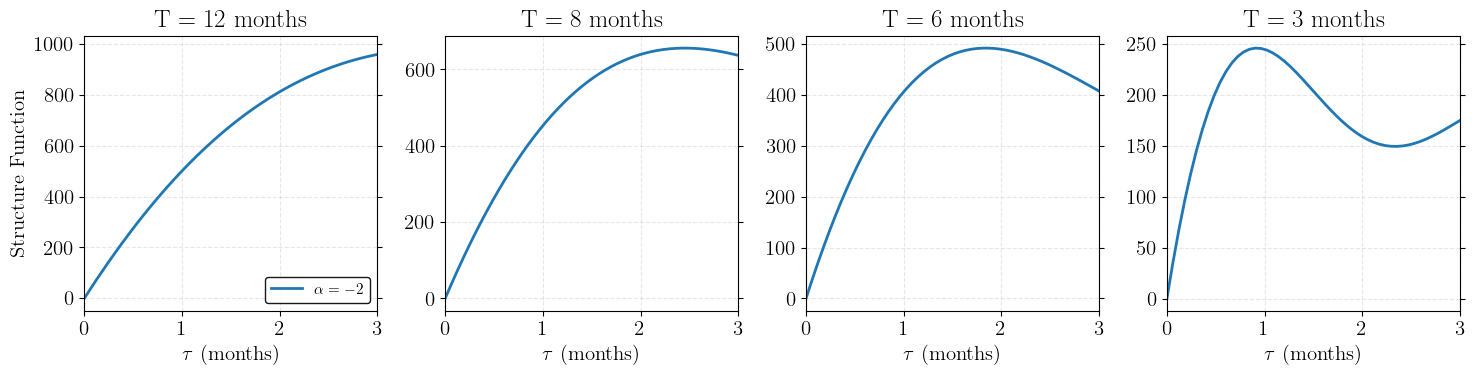

In [50]:
# Set plotting parameters
idx_alpha = np.argmin(np.abs(np.array(alpha_values) - 2))
colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:orange'] 

# Create figure and axes 
fig, axes = plt.subplots(1, nfmin, figsize=(15, 4))

# Loop through f_min values 
for k in range(0,len(fmin_values)): 

    # Set axis object 
    ax = axes[k]

    # Plot the specified alpha value 
    ax.plot(tau_months, S_2[:,k,idx_alpha], '-', lw = 2, color = 'tab:blue', label=rf"$\alpha = -{alpha_values[idx_alpha]}$") 

    # Set axis attributes 
    ax.set_title(f'T = {int(T_months[k])} months')
    ax.set_xlabel(r'$\tau$ (months)')
    ax.set_xticks(np.arange(0,12+1,1))
    ax.set_xlim(-0,x_max)
    ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
    ax.grid(True,linestyle='--',alpha=0.3)

    if k == 0: 
        ax.set_ylabel('Structure Function')
        ax.legend(loc='lower right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Display 
plt.tight_layout()
plt.show()

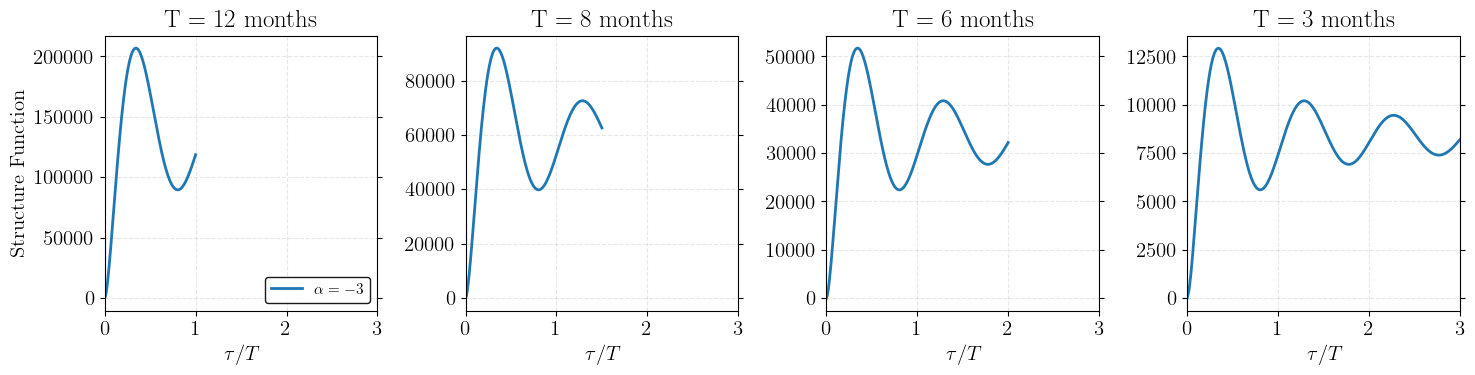

In [52]:
# Set plotting parameters
idx_alpha = np.argmin(np.abs(np.array(alpha_values) - 3))

# Create figure and axes 
fig, axes = plt.subplots(1, nfmin, figsize=(15, 4))

# Loop through f_min values 
for k in range(0,len(fmin_values)): 

    # Set axis object 
    ax = axes[k]

    # Plot the specified alpha value 
    ax.plot(tau_months/T_months[k], S_2[:,k,idx_alpha], '-', lw = 2, color = 'tab:blue', label=rf"$\alpha = -{alpha_values[idx_alpha]}$") 

    # Set axis attributes 
    ax.set_title(f'T = {int(T_months[k])} months')
    ax.set_xlabel(r'$\tau/T$')
    ax.set_xticks(np.arange(0,12+1,1))
    ax.set_xlim(-0,x_max)
    ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
    ax.grid(True,linestyle='--',alpha=0.3)

    if k == 0: 
        ax.set_ylabel('Structure Function')
        ax.legend(loc='lower right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Display 
plt.tight_layout()
plt.show()

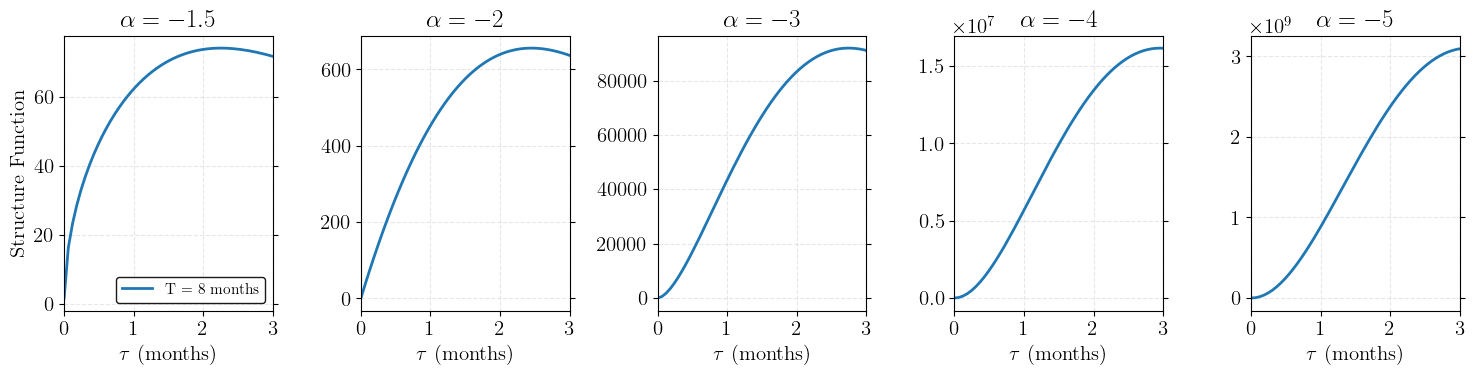

In [46]:
# Set plotting parameters
idx_T = np.argmin(np.abs(np.array(T_months) - 8))
x_max = 3

# Create figure and axes 
fig, axes = plt.subplots(1, nalpha, figsize=(15, 4))

# Loop through alpha values 
for k in range(0,len(alpha_values)): 

    # Set axis object 
    ax = axes[k]

    # Plot the specified alpha value 
    ax.plot(tau_months, S_2[:,idx_T,k], '-', lw = 2, color = 'tab:blue', label=f"T = {int(T_months[idx_T])} months") 

    # Set axis attributes 
    ax.set_title(rf"$\alpha = -{alpha_values[k]}$")
    ax.set_xlabel(r'$\tau$ (months)')
    ax.set_xticks(np.arange(0,12+1,1))
    ax.set_xlim(-0,x_max)
    ax.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
    ax.grid(True,linestyle='--',alpha=0.3)

    if k == 0: 
        ax.set_ylabel('Structure Function')
        ax.legend(loc='lower right', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Display 
plt.tight_layout()
plt.show()

In [78]:
def struct_scale_analytic(fmin, fmax, alpha):
    """
    Function for computing the analytic scale for a power-law spectrum from the structure function. 

    Parameters
    ----------
    fmin : float
        Minimum frequency.
    fmax : float
        Maximum frequency.
    alpha : float
        Power-law exponent.

    Returns
    -------
    T : ndarray (complex)
        Asymptotic scale.
    R0 : float
        Variance (R at zero lag).
    """

    #-------------------------------# 
    # Compute R(0) (Variance)
    #-------------------------------# 
    if np.isclose(alpha, 1.0):
        R0 = np.log(fmax / fmin)
    else:
        R0 = (fmax**(1 - alpha) - fmin**(1 - alpha)) / (1 - alpha)

    #-------------------------------# 
    # Compute Phi(\alpha)
    #-------------------------------# 
    if np.isclose(alpha, 2.0): 
        phi = np.log(fmax / fmin)
    else: 
        phi = (fmax**(2-alpha) - fmin**(2-alpha))/(2 - alpha)
        
    #-------------------------------# 
    # Compute asymptotic scale
    #-------------------------------# 
    T = R0/(2 * np.pi * phi)

    return T, R0

In [101]:
def struct_scale_analytic(fmin, fmax, alpha, order=1):
    """
    Function for computing the analytic scale for a power-law spectrum from the structure function.

    Parameters
    ----------
    fmin : float
        Minimum frequency.
    fmax : float
        Maximum frequency.
    alpha : float
        Power-law exponent.
    order : int, optional
        Order of the asymptotic expansion (1 or 2). Default is 1.

    Returns
    -------
    T : float
        Asymptotic break scale tau*.
    R0 : float
        Variance (R at zero lag).
    """

    #-------------------------------#
    # Compute R(0) (Variance)
    #-------------------------------#
    if np.isclose(alpha, 1.0):
        R0 = np.log(fmax / fmin)
    else:
        R0 = (fmax**(1 - alpha) - fmin**(1 - alpha)) / (1 - alpha)

    #-------------------------------#
    # Compute Phi_1 (first-order coefficient)
    #-------------------------------#
    if np.isclose(alpha, 2.0):
        Phi1 = np.log(fmax / fmin)
    else:
        Phi1 = (fmax**(2 - alpha) - fmin**(2 - alpha)) / (2 - alpha)

    #-------------------------------#
    # First-order break scale
    #-------------------------------#
    if order == 1:
        T = R0 / (2 * np.pi * Phi1)
        return T, R0

    #-------------------------------#
    # Second-order break scale
    #-------------------------------#
    elif order == 2:

        # Compute Phi_2
        if np.isclose(alpha, 3.0):
            Phi2 = np.log(fmax / fmin)
        else:
            Phi2 = (fmax**(3 - alpha) - fmin**(3 - alpha)) / (3 - alpha)

        C1 = 4 * np.pi * Phi1
        C2 = 4 * np.pi**2 * Phi2

        discriminant = C1**2 - 8 * R0 * C2

        # Expansion validity ratio: should be << 1
        T1 = R0 / (2 * np.pi * Phi1)
        expansion_ratio = C2 * T1 / C1
        if expansion_ratio > 0.1:
            warnings.warn(
                f"Second-order term is {100*expansion_ratio:.1f}% of first-order term "
                f"(ratio={expansion_ratio:.3f}). Expansion may not be valid. "
                f"Consider using order=1.",
                UserWarning
            )

        if discriminant < 0:
            warnings.warn(
                f"Negative discriminant ({discriminant:.3e}): falling back to order=1.",
                UserWarning
            )
            T = T1
        else:
            T = (C1 - np.sqrt(discriminant)) / (2 * C2)

        return T, R0

    else:
        raise ValueError(f"Order must be 1 or 2, got {order}.")

Set parameters for computing the autocorrelation function

In [102]:
# Set sampling parameters 
dt = 1/24                                                   # Sampling interval (units: days) 
T  = np.flipud(np.arange(0.025, 1 + 0.025, 0.025) * (365))  # Record duration (units: days)

# Convert time to units of months 
days_per_month = 365 / 12 
T_months = T / days_per_month

# Set maximum and minimum frequency in units of cpd
fmax = 1/dt                                         
fmin_values = 1/T               

# Set spectral slope values 
alpha_values = np.arange(0.1,5+0.1,0.1)

Compute asymptotic scale

In [105]:
# Set parameters
nfmin, nalpha = len(fmin_values), len(alpha_values)

# Initialize array
T_asym = np.zeros((nfmin, nalpha))

# Loop through f_min (low frequency bound)
for i, fmin in enumerate(fmin_values):

    # Loop through spectral slope
    for j, alpha in enumerate(alpha_values):

        # Compute the autocorrelation function 
        T_asym[i,j], _ = struct_scale_analytic(fmin, fmax, alpha, order = 2)   # Units: days

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/820394268.py:67: UserWarning: Second-order term is 69.1% of first-order term (ratio=0.691). Expansion may not be valid. Consider using order=1.
  warnings.warn(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/820394268.py:75: UserWarning: Negative discriminant (-1.357e+07): falling back to order=1.
  warnings.warn(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/820394268.py:67: UserWarning: Second-order term is 72.3% of first-order term (ratio=0.723). Expansion may not be valid. Consider using order=1.
  warnings.warn(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/820394268.py:75: UserWarning: Negative discriminant (-8.576e+06): falling back to order=1.
  warnings.warn(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_45299/820394268.py:67: UserWarning: Second-order term is 76.3% of first-order term (ratio=0.763). Expansion may not be valid. Consider using or

Plot the asymptotic scale as a function of spectral slope and duration 

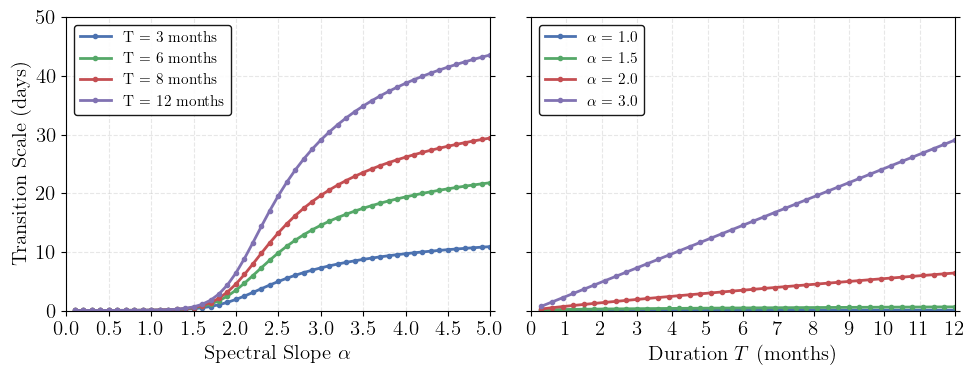

In [106]:
# Set plotting parameters
colors_decor = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
alpha_p    = [1, 1.5, 2, 3]
T_months_p = [3,6,8,12]

# Create figure and axes 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#-------------------# 
# Subplot 1
#-------------------# 
ax = axes[0]

# Loop through a subset of T values 
for k, iT in enumerate(T_months_p): 

    # Find index value
    idx_T = np.argmin(np.abs(T_months - iT))

    # Plot the decorrelation scale as a function of spectral slope
    ax.plot(alpha_values, T_asym[idx_T,:], '.-', lw = 2, label=f"T = {int(T_months[idx_T])} months", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel('Transition Scale (days)')
ax.set_xticks(np.arange(0,5+0.5,0.5))
ax.set_yticks(np.arange(0,50+10,10))
ax.set_xlim(0,5)
ax.set_ylim(0,50)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper left', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

#-------------------# 
# Subplot 2
#-------------------# 
ax = axes[1]

# Loop through a subset of alpha values 
for k, ialpha in enumerate(alpha_p): 

    # Find index value
    idx_alpha = np.argmin(np.abs(np.array(alpha_values) - ialpha))

    # Plot the decorrelation scale as a function of f_min
    ax.plot(T_months, T_asym[:,idx_alpha], '.-', lw = 2, label=rf"$\alpha =$ {np.round(alpha_values[idx_alpha],1)}", color=colors_decor[k]) 

# Set axis attributes 
ax.set_xlabel(r'Duration $T$ (months)')
ax.set_xticks(np.arange(0,12+1,1))
ax.set_yticks(np.arange(0,50+10,10))
ax.set_xlim(0,12)
ax.set_ylim(0,50)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(loc='upper left', fontsize=fontsize-4, framealpha=0.9, edgecolor='black')

# Display 
plt.tight_layout()
plt.show()